<h2>
  <span style="color:#C71585">Laila Marqoum:</span> <span style="color:black;">IID3</span>
</h2>

<h2>
  <span style="color:#C71585">TP 2:</span> <span style="color:black;">Logique floue et intégration du ML</span>
</h2>

<h2>
  <span style="color:pink;">Étapes du TP :</span>
</h2>
<ul style="color:black;">
  <li>Génération d’un dataset synthétique via le modèle flou (<code>scikit-fuzzy</code>).</li>
  <li>Réalisation d’une régression (ex. <code>RandomForestRegressor</code>).</li>
  <li>Calcul des métriques d’évaluation : <strong>MAE</strong> et <strong>MSE</strong>.</li>
  <li>Comparaison des performances entre la <strong>Logique Floue</strong> et le <strong>Machine Learning</strong>.</li>
</ul>


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ---------------------------
# 1 Définition des variables floues
# ---------------------------
Distance_to_next_car = ctrl.Antecedent(np.arange(0, 30.1, 0.1), 'Distance_to_next_car')
Speed_change = ctrl.Antecedent(np.arange(-20, 20.1, 0.1), 'Speed_change')
Acceleration_Adjust = ctrl.Consequent(np.arange(-3, 3.1, 0.1), 'Acceleration_Adjust')

# ---------------------------
# 2 Fonctions d’appartenance
# ---------------------------
# Distance
Distance_to_next_car['v_small'] = fuzz.trapmf(Distance_to_next_car.universe, [0, 0, 2, 5])
Distance_to_next_car['small']   = fuzz.trimf(Distance_to_next_car.universe, [3, 6, 9])
Distance_to_next_car['perfect'] = fuzz.trimf(Distance_to_next_car.universe, [8, 12, 16])
Distance_to_next_car['big']     = fuzz.trimf(Distance_to_next_car.universe, [14, 18, 22])
Distance_to_next_car['v_big']   = fuzz.trapmf(Distance_to_next_car.universe, [20, 25, 30, 30])

# Speed_change
Speed_change['declining'] = fuzz.trapmf(Speed_change.universe, [-20, -20, -10, -2])
Speed_change['constant']  = fuzz.trimf(Speed_change.universe, [-5, 0, 5])
Speed_change['growing']   = fuzz.trapmf(Speed_change.universe, [2, 10, 20, 20])

# Acceleration_Adjust
Acceleration_Adjust['neg_big']   = fuzz.trapmf(Acceleration_Adjust.universe, [-3, -3, -2.5, -1.5])
Acceleration_Adjust['neg_small'] = fuzz.trimf(Acceleration_Adjust.universe, [-2, -1, 0])
Acceleration_Adjust['zero']      = fuzz.trimf(Acceleration_Adjust.universe, [-0.5, 0, 0.5])
Acceleration_Adjust['pos_small'] = fuzz.trimf(Acceleration_Adjust.universe, [0, 1, 2])
Acceleration_Adjust['pos_big']   = fuzz.trapmf(Acceleration_Adjust.universe, [1.5, 2.5, 3, 3])

# ---------------------------
# 3 Définition des 15 règles floues
# ---------------------------
rules = [
    # v_small
    ctrl.Rule(Distance_to_next_car['v_small'] & Speed_change['declining'], Acceleration_Adjust['neg_small']),
    ctrl.Rule(Distance_to_next_car['v_small'] & Speed_change['constant'], Acceleration_Adjust['neg_big']),
    ctrl.Rule(Distance_to_next_car['v_small'] & Speed_change['growing'], Acceleration_Adjust['neg_big']),
    
    # small
    ctrl.Rule(Distance_to_next_car['small'] & Speed_change['declining'], Acceleration_Adjust['zero']),
    ctrl.Rule(Distance_to_next_car['small'] & Speed_change['constant'], Acceleration_Adjust['neg_small']),
    ctrl.Rule(Distance_to_next_car['small'] & Speed_change['growing'], Acceleration_Adjust['neg_big']),
    
    # perfect
    ctrl.Rule(Distance_to_next_car['perfect'] & Speed_change['declining'], Acceleration_Adjust['pos_small']),
    ctrl.Rule(Distance_to_next_car['perfect'] & Speed_change['constant'], Acceleration_Adjust['zero']),
    ctrl.Rule(Distance_to_next_car['perfect'] & Speed_change['growing'], Acceleration_Adjust['neg_small']),
    
    # big
    ctrl.Rule(Distance_to_next_car['big'] & Speed_change['declining'], Acceleration_Adjust['pos_big']),
    ctrl.Rule(Distance_to_next_car['big'] & Speed_change['constant'], Acceleration_Adjust['pos_small']),
    ctrl.Rule(Distance_to_next_car['big'] & Speed_change['growing'], Acceleration_Adjust['zero']),
    
    # v_big
    ctrl.Rule(Distance_to_next_car['v_big'] & Speed_change['declining'], Acceleration_Adjust['pos_big']),
    ctrl.Rule(Distance_to_next_car['v_big'] & Speed_change['constant'], Acceleration_Adjust['pos_big']),
    ctrl.Rule(Distance_to_next_car['v_big'] & Speed_change['growing'], Acceleration_Adjust['pos_small'])
]

# ---------------------------
# 4 Construction du système flou
# ---------------------------
system = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(system)

# ---------------------------
# 5 Génération du dataset synthétique
# ---------------------------
n = 1000
X_dist = np.random.uniform(0, 30, n)
X_speed = np.random.uniform(-20, 20, n)
y_accel = []

for d, s in zip(X_dist, X_speed):
    simulation.input['Distance_to_next_car'] = d
    simulation.input['Speed_change'] = s
    simulation.compute()
    y_accel.append(simulation.output['Acceleration_Adjust'])

y_accel = np.array(y_accel)

# ---------------------------
# 6 Entraînement du modèle ML (Random Forest)
# ---------------------------
X = np.column_stack((X_dist, X_speed))
X_train, X_test, y_train, y_test = train_test_split(X, y_accel, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédiction
y_pred = model.predict(X_test)

# ---------------------------
# 7 Évaluation des performances
# ---------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Erreur absolue moyenne (MAE): {mae:.4f}")
print(f"Erreur quadratique moyenne (MSE): {mse:.4f}")

# ---------------------------
# 8 Comparaison logique floue vs ML
# ---------------------------
print("\n--- Comparaison ---")
print(" Logique floue :")
print("- Avantage : Très explicable (règles linguistiques simples).")
print("- Permet de modéliser le raisonnement humain.")
print("- Inconvénient : Performance limitée si les relations sont très complexes.\n")

print(" Machine Learning :")
print("- Avantage : Haute précision avec suffisamment de données.")
print("- Capable de généraliser sur de nouvelles situations.")
print("- Inconvénient : Boîte noire, difficile à interpréter.")


Erreur absolue moyenne (MAE): 0.0200
Erreur quadratique moyenne (MSE): 0.0022

--- Comparaison ---
 Logique floue :
- Avantage : Très explicable (règles linguistiques simples).
- Permet de modéliser le raisonnement humain.
- Inconvénient : Performance limitée si les relations sont très complexes.

 Machine Learning :
- Avantage : Haute précision avec suffisamment de données.
- Capable de généraliser sur de nouvelles situations.
- Inconvénient : Boîte noire, difficile à interpréter.


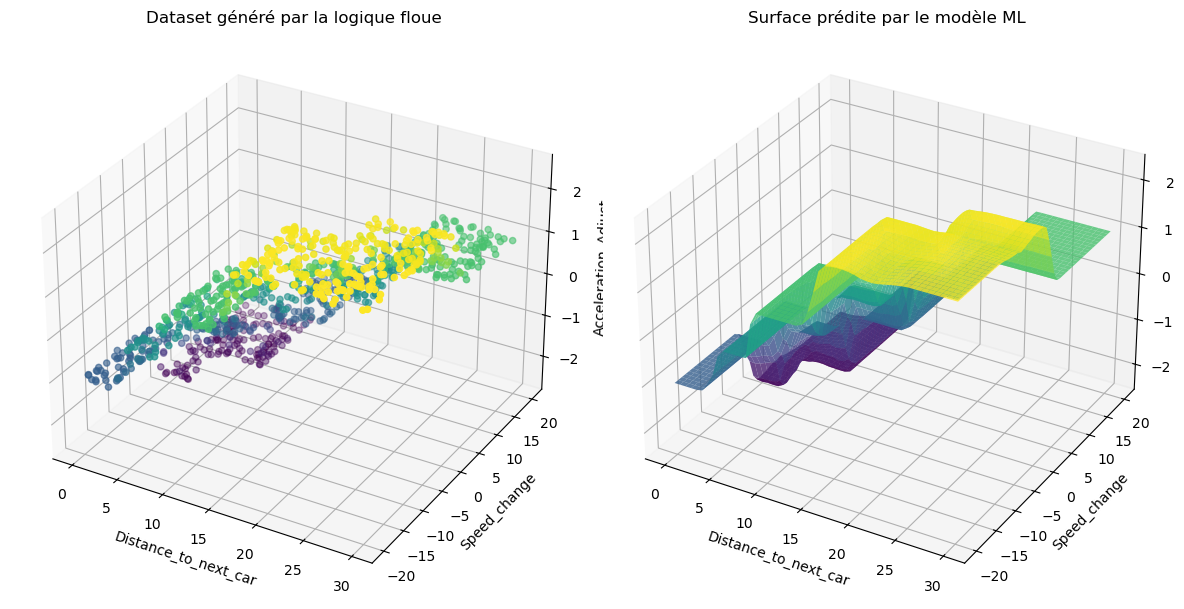

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# 9 Visualisation 3D du dataset flou
# ---------------------------
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_dist, X_speed, y_accel, c=y_accel, cmap='viridis', marker='o')
ax.set_xlabel('Distance_to_next_car')
ax.set_ylabel('Speed_change')
ax.set_zlabel('Acceleration_Adjust')
ax.set_title('Dataset généré par la logique floue')

# ---------------------------
# 10 Visualisation de la surface ML
# ---------------------------
# Créer une grille pour la prédiction
dist_grid = np.linspace(0, 30, 50)
speed_grid = np.linspace(-20, 20, 50)
dist_mesh, speed_mesh = np.meshgrid(dist_grid, speed_grid)
X_grid = np.column_stack([dist_mesh.ravel(), speed_mesh.ravel()])
y_grid_pred = model.predict(X_grid).reshape(dist_mesh.shape)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(dist_mesh, speed_mesh, y_grid_pred, cmap='viridis', alpha=0.8)
ax2.set_xlabel('Distance_to_next_car')
ax2.set_ylabel('Speed_change')
ax2.set_zlabel('Acceleration_Adjust')
ax2.set_title('Surface prédite par le modèle ML')

plt.tight_layout()
plt.show()
